In [1]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

from spatial_tcr.colors import colors_dict
from spatial_tcr.tcr import aggregate_trv_expression, get_tcr_genes
from spatial_tcr.utils import remove_background

# Set the verbosity level
sc.settings.verbosity = 3

from matplotlib import rcParams

# font_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
# arial = font_manager.FontProperties(fname=font_path).get_name()
# print(type(arial))
# print(arial)
sns.set_theme(style="ticks", context="paper")
sc.settings._vector_friendly = True
arial = "Arial"
rcParams["font.family"] = arial

figure_dir = "figures/kidney/main-figures/figure_1"
os.makedirs(figure_dir, exist_ok=True)

/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr


In [2]:
path = "data/xenium/processed/03-kidney_tcr_classified.h5ad"
adata = sc.read_h5ad(path)
adata.X = adata.layers["counts"].copy()
# adata.obs["sample"] = [name.split("_output-")[-1] for name in adata.obs_names]
adata

AnnData object with n_obs × n_vars = 510139 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'graph'
    obsm: 'cell_type_no_tcr_probs', 'spatial'
    layers: 'counts'

In [3]:
celltype_col = "subclass.l1"
celltype_col = "cell_type_no_tcr"

In [4]:
adata.obs[celltype_col].nunique()

27

Text(0, 0.5, 'Count')

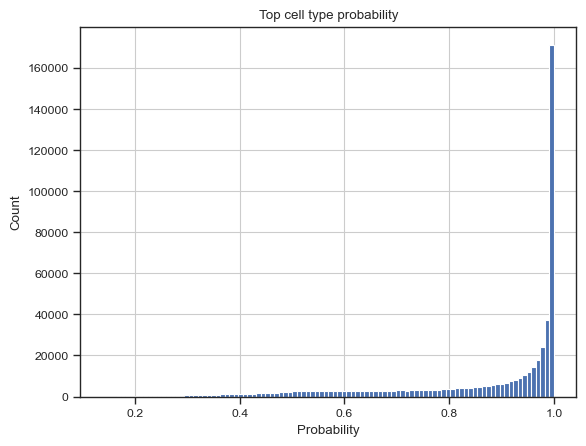

In [5]:
ax = adata.obs["cell_type_no_tcr_prob"].hist(bins=100)
ax.set_title("Top cell type probability")
ax.set_xlabel("Probability")
ax.set_ylabel("Count")

In [6]:
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()

normalizing counts per cell
    finished (0:00:03)


## Plot UMAP

In [7]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

computing PCA
    with n_comps=50
    finished (0:00:07)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:34)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:07:53)


In [8]:
# # save umap coordinates to csv
# pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names).to_csv(
#     "data/xenium/processed/umap_coordinates.csv"
# )

try:
    umap_coords = pd.read_csv("data/xenium/umap_coordinates.csv", index_col=0)
    adata.obsm["X_umap"] = umap_coords.loc[adata.obs_names].values
except Exception as err:
    raise ValueError("No umap coordinates found") from err
umap_coords

,0,1
aaaombci-1output-XETG00088__0029040__Region_2__20240719__095641,11.426276,3.087938
aaapplje-1output-XETG00088__0029040__Region_2__20240719__095641,9.136224,3.756617
aabafpch-1output-XETG00088__0029040__Region_2__20240719__095641,6.703707,2.819945
aabcmlje-1output-XETG00088__0029040__Region_2__20240719__095641,9.079102,7.131573
aabecado-1output-XETG00088__0029040__Region_2__20240719__095641,-0.761004,-0.070396
...,...,...
ojhmonnc-1output-XETG00088__0029040__Region_5__20240719__095642,10.701680,2.742868
ojhngikd-1output-XETG00088__0029040__Region_5__20240719__095642,8.304700,3.403561
ojibodbj-1output-XETG00088__0029040__Region_5__20240719__095642,5.789227,7.732293
ojicdocl-1output-XETG00088__0029040__Region_5__20240719__095642,7.409301,6.540338


In [9]:
# celltypes = adata.obs[celltype_col].unique()
# palette = sns.color_palette("husl", len(celltypes))
# palette = {ct: palette[i] for i, ct in enumerate(celltypes)}
# palette["T"] = "red"

# palette_alpha = {
#     ct: mcolors.to_rgba(palette[ct], alpha=0.25 if ct != "T" else 1)
#     for ct in palette.keys()
# }

palette = colors_dict

In [10]:
def change_label_position(ax, axis="x", scale=0.5):
    if axis == "x":
        label = ax.xaxis.label
    elif axis == "y":
        label = ax.yaxis.label
    else:
        raise ValueError(f"Invalid axis: {axis}")
    x, y = label.get_position()
    transform = label.get_transform()
    if axis == "x":
        label.set_position((x * scale, y))
    elif axis == "y":
        label.set_position((x, y * scale))
    label.set_transform(transform)

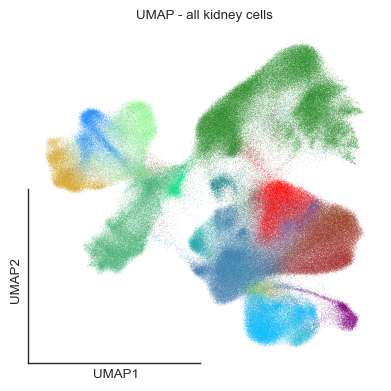

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(
    adata, color=celltype_col, show=False, ax=ax, palette=palette, legend_loc=None
)
ax.set_title("UMAP - all kidney cells")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# shorten the spines
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.spines["left"].set_bounds(ylim[0], ylim[1] * 0.3)
ax.spines["bottom"].set_bounds(xlim[0], xlim[1] * 0.3)

change_label_position(ax, axis="x", scale=0.5)
change_label_position(ax, axis="y", scale=0.5)

plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, "umap_all_cells.pdf"), dpi=300, bbox_inches="tight"
)

## Plot cell type composition

/tmp/ipykernel_9081/2616033144.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


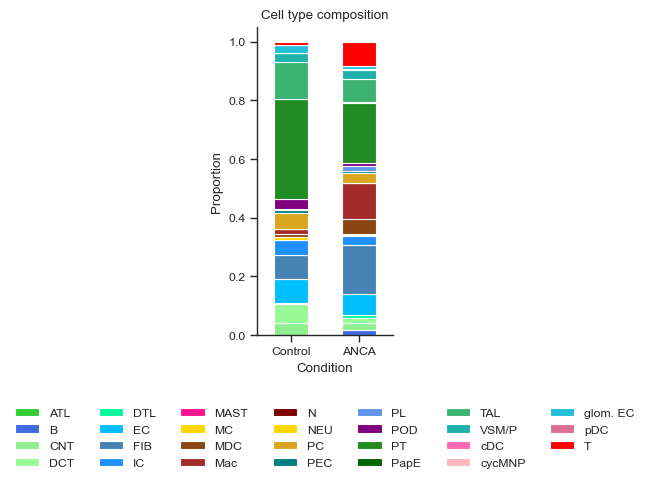

In [12]:
# Create stacked bar plot of cell type proportions by disease
proportions = (
    adata.obs.groupby("condition", observed=True)[celltype_col]
    .value_counts(normalize=True)
    .unstack()
)

# reorder
condition_order = ["Control", "ANCA"]
proportions = proportions.reindex(condition_order)

col_order = [ct for ct in proportions.columns if ct != "T"] + ["T"]
proportions = proportions[col_order]

fig, ax = plt.subplots(figsize=(1.75, 4))
proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=palette,
)

ax.set_title("Cell type composition")
ax.set_xlabel("Condition")
ax.set_ylabel("Proportion")
# ax.get_legend().remove()
ax.legend(
    bbox_to_anchor=(0.5, -0.2),
    loc="upper center",
    ncol=7,
    bbox_transform=ax.transAxes,
    frameon=False,
)

sns.despine(ax=ax, right=True, top=True)

# set x-axis labels to ANCA and Control
ax.set_xticklabels(condition_order)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, "cell_type_composition.pdf"), dpi=300, bbox_inches="tight"
)

## Plot cell types on sample

In [13]:
sample = adata.obs["sample"].unique()[2]
sample = "XETG00088__0029041__Region_3__20240719__095642"

/tmp/ipykernel_9081/3735610679.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  ax = sc.pl.spatial(


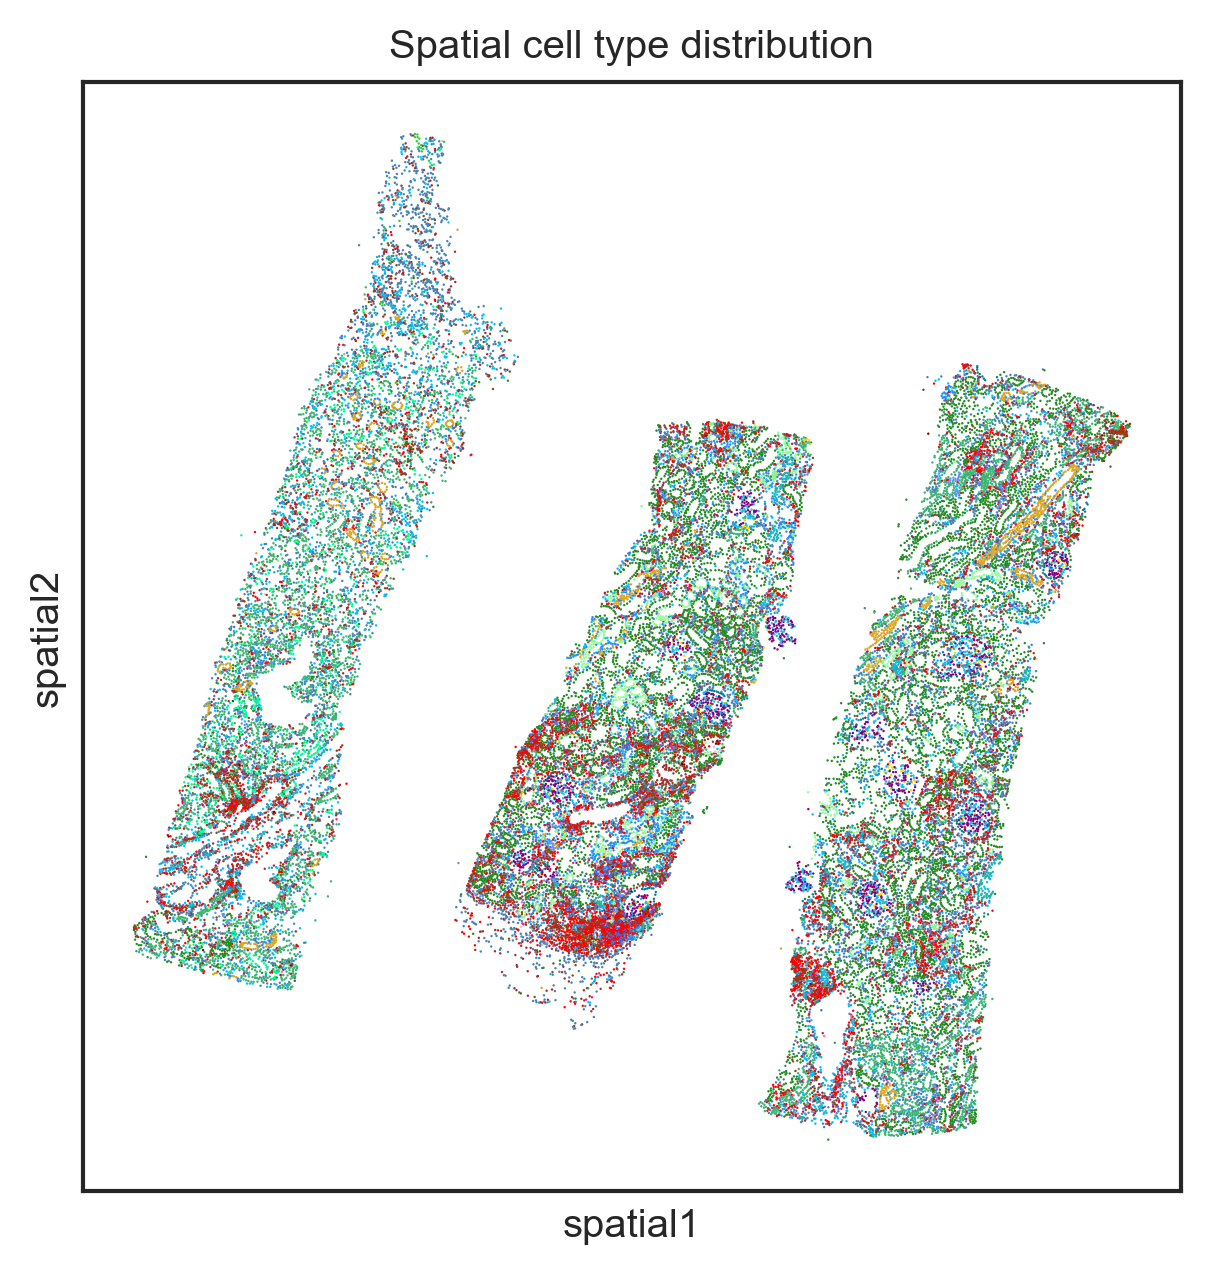

In [14]:
plt.rcParams["figure.dpi"] = 300


# sample = adata.obs["sample"].unique()[0]

ad_sub = adata[adata.obs["sample"] == sample].copy()
ax = sc.pl.spatial(
    ad_sub,
    color=celltype_col,
    show=False,
    spot_size=10,
    palette=palette,
    legend_loc=None,
)[0]
ax.set_title("Spatial cell type distribution")

plt.rcParams["figure.dpi"] = 100

## Marker expression

In [15]:
adata.X = adata.layers["counts"].copy()
ad_tmp = aggregate_trv_expression(adata)
sc.pp.normalize_total(ad_tmp)
sc.pp.log1p(ad_tmp)

Found 54 TRAV genes, 61 TRBV genes, 3 TRDV genes, 14 TRGV genes
normalizing counts per cell
    finished (0:00:00)


/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


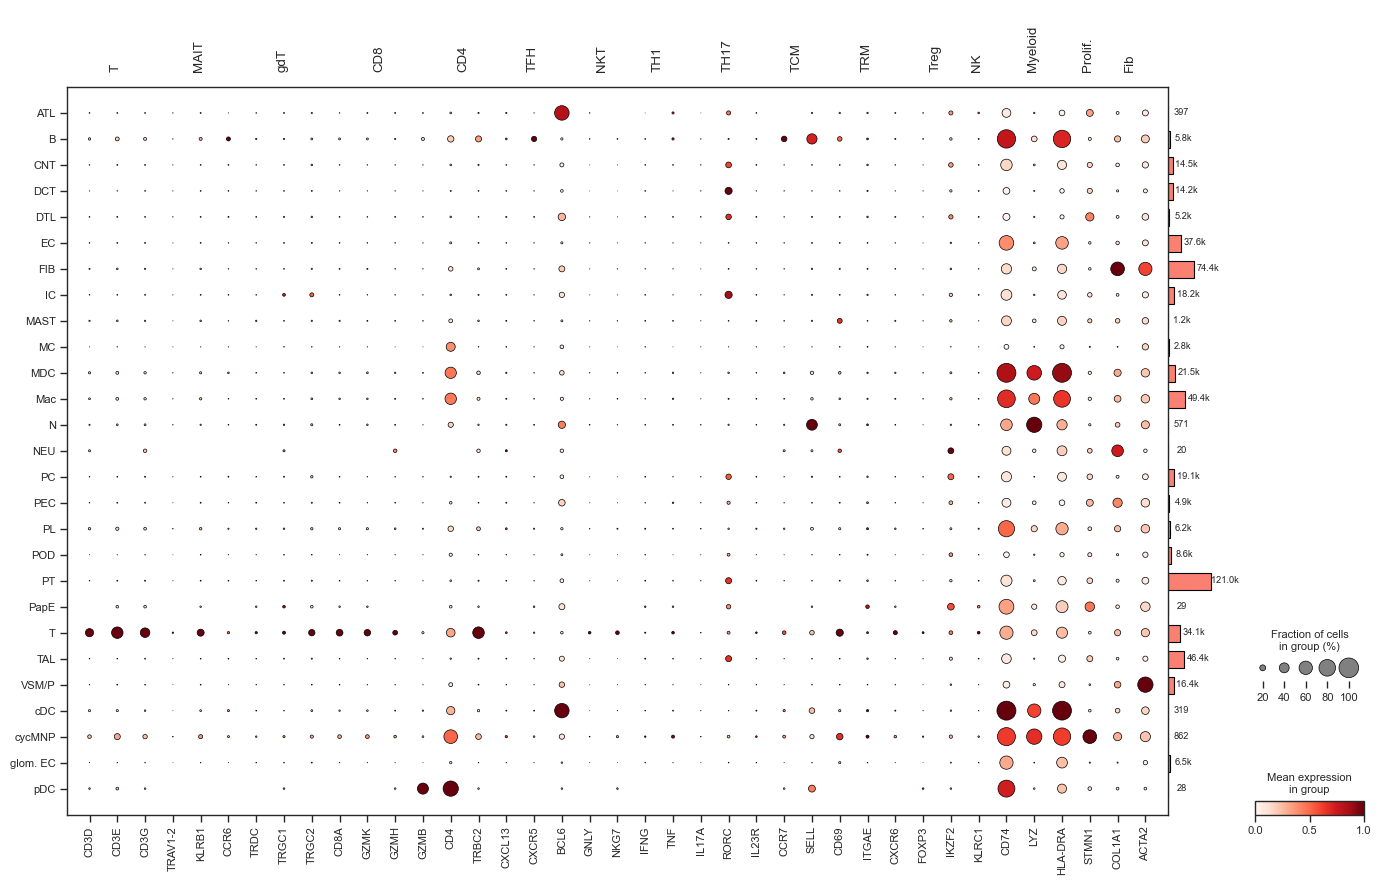

In [16]:
markers = {
    "Tcell": ["CD4", "CD8A", "CD3E", "CD3G", "CD3D", "TRAC", "TRBC1", "TRBC2"],
    "Bcell": ["CD19", "MS4A1"],
    "Pod": ["PODXL"],
}
markers = {
    "T": ["CD3D", "CD3E", "CD3G"],
    "MAIT": ["TRAV1-2", "KLRB1", "CCR6"],
    "gdT": ["TRDC", "TRGC1", "TRGC2"],
    "CD8": [
        "CD8A",
        "GZMK",
        "GZMH",
        "GZMB",
    ],
    "CD4": ["CD4", "TRBC2"],
    "TFH": ["CXCL13", "CXCR5", "BCL6"],
    "NKT": ["GNLY", "NKG7"],
    "TH1": ["IFNG", "TNF"],
    "TH17": ["IL17A", "RORC", "IL23R"],
    "TCM": ["CCR7", "SELL"],
    "TRM": ["CD69", "ITGAE", "CXCR6"],
    "Treg": ["FOXP3", "IKZF2"],
    "NK": ["KLRC1"],
    "Myeloid": ["CD74", "LYZ", "HLA-DRA"],
    "Prolif.": ["STMN1"],
    "Fib": ["COL1A1", "ACTA2"],
}

adata.X = adata.layers["log1p"].copy()

dp = sc.pl.dotplot(
    adata,
    markers,
    groupby=celltype_col,
    return_fig=True,
    standard_scale="var",
    cmap="Reds",
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

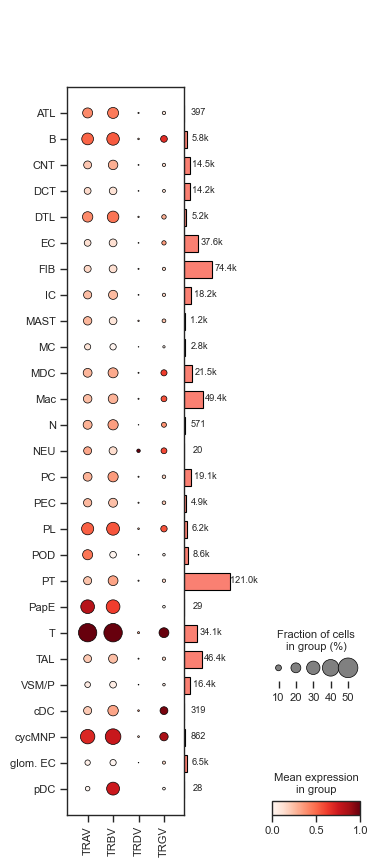

In [17]:
markers = ["TRAV", "TRBV", "TRDV", "TRGV"]

dp = sc.pl.dotplot(
    ad_tmp,
    markers,
    groupby=celltype_col,
    return_fig=True,
    standard_scale="var",
    cmap="Reds",
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

## Check specific TRV expression

Found 54 TRAV genes, 61 TRBV genes, 3 TRDV genes, 14 TRGV genes


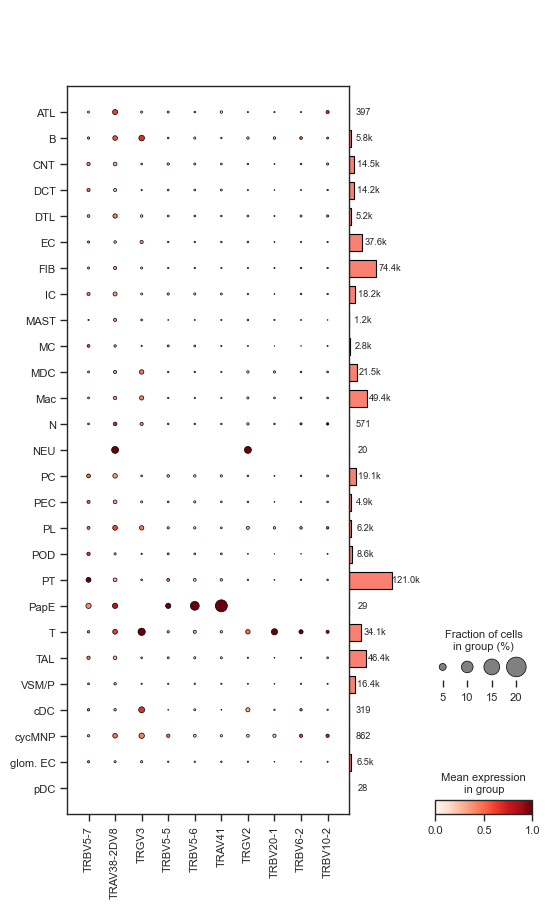

In [18]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)

# get only the top k expressed tv genes
top_k = 10
tot_counts = adata[:, tv_genes].X.toarray().sum(axis=0)
top_k_genes = (
    pd.DataFrame({"gene": tv_genes, "counts": tot_counts})
    .sort_values("counts", ascending=False)["gene"]
    .iloc[:top_k]
    .tolist()
)


dp = sc.pl.dotplot(
    adata,
    top_k_genes,
    groupby="cell_type_no_tcr",
    return_fig=True,
    standard_scale="var",
    cmap="Reds",
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

## Check with count cutoff

In [19]:
remove_background(adata, greater=1, layer_in="counts", layer_out="counts_cut")

In [20]:
adata.X = adata.layers["counts_cut"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [21]:
ad_tmp = aggregate_trv_expression(adata)
sc.pp.normalize_total(ad_tmp)
sc.pp.log1p(ad_tmp)

Found 54 TRAV genes, 61 TRBV genes, 3 TRDV genes, 14 TRGV genes
normalizing counts per cell
    finished (0:00:00)


/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


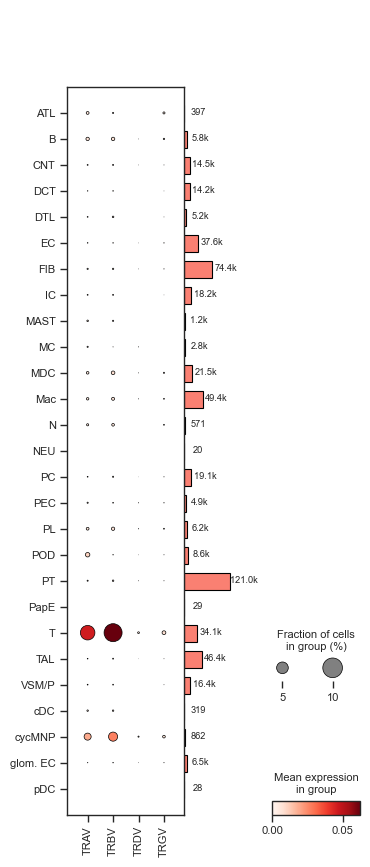

In [22]:
markers = ["TRAV", "TRBV", "TRDV", "TRGV"]

dp = sc.pl.dotplot(
    ad_tmp,
    markers,
    groupby="cell_type_no_tcr",
    return_fig=True,
    # standard_scale="var",
    cmap="Reds",
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

## Differential expression

In [23]:
# exclude trv genes?
# trv_genes = get_tcr_genes(adata)[-1]
# ad_sub = adata[~adata.var_names.isin(trv_genes)].copy()

In [24]:
sc.tl.rank_genes_groups(adata, groupby="cell_type_no_tcr", method="wilcoxon")

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:18)


/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/scanpy/tools/_rank_genes_g

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cell_type_no_tcr']`


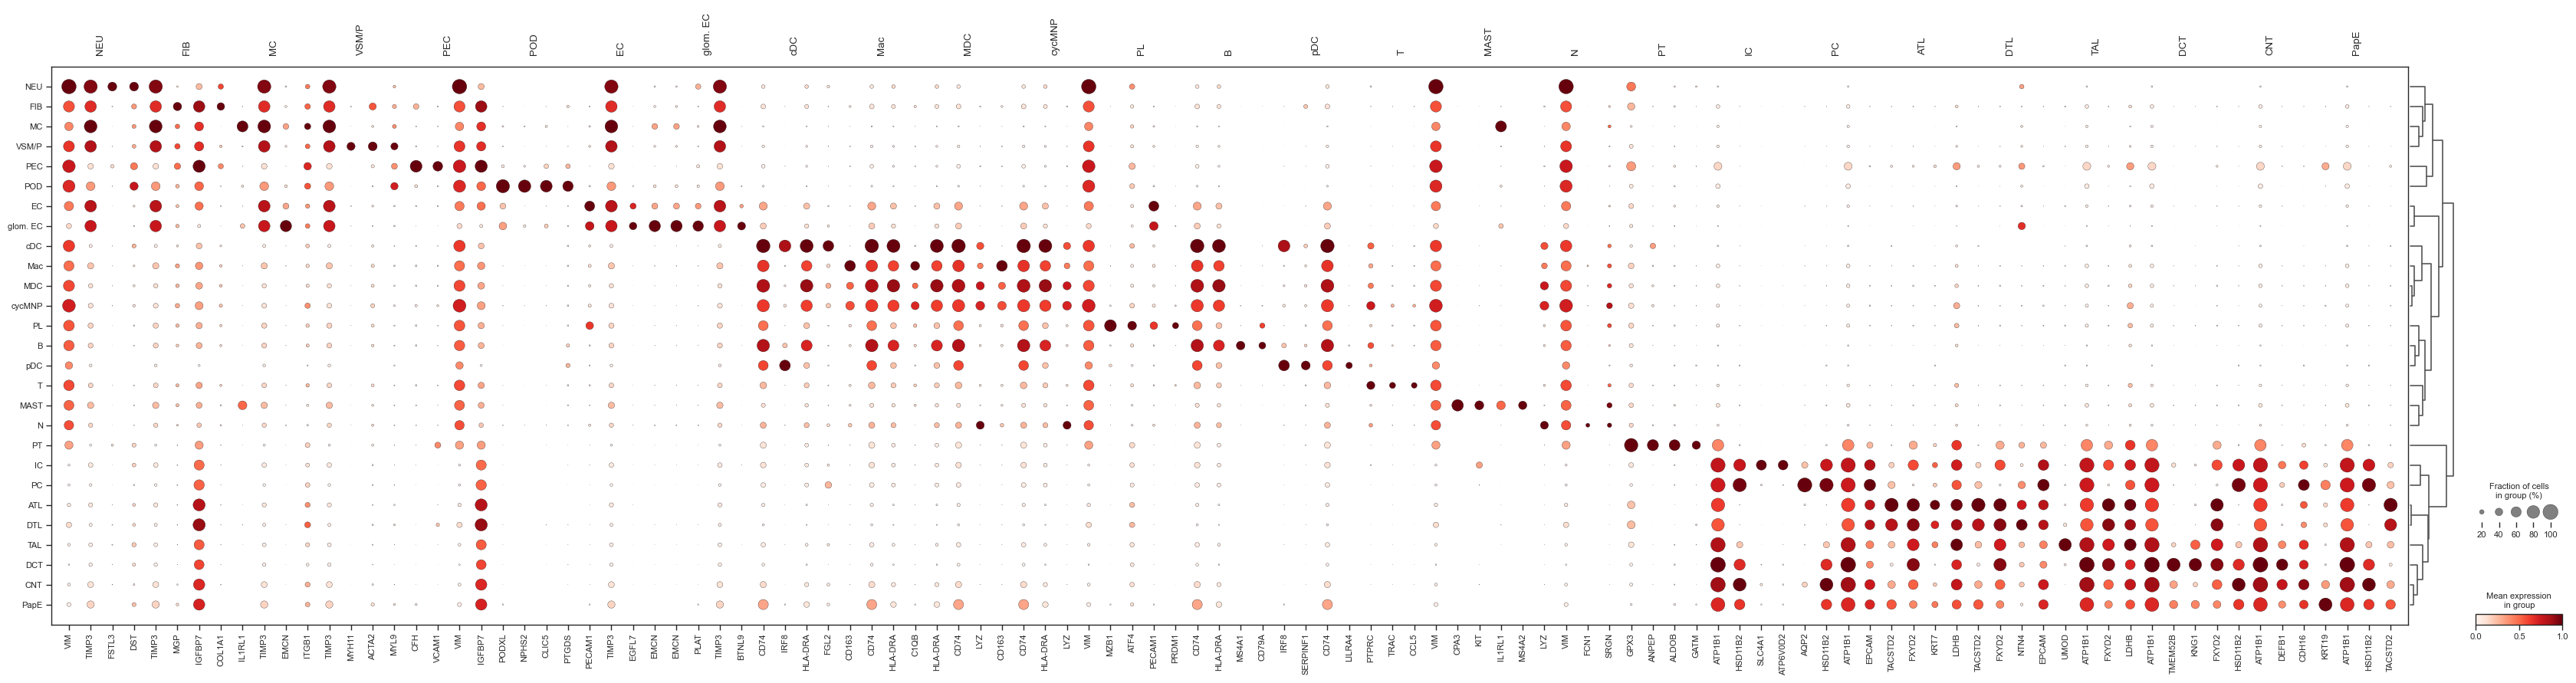

In [25]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="cell_type_no_tcr", standard_scale="var", n_genes=4
)